In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os



CSVLOC = "./csv/Cleaned_DF.csv"

# 1. Cargar el "cerebro" y las "gafas" (Modelo y Escalador)
folder = 'joblibs'
try:
    modelo = joblib.load(os.path.join(folder, 'rf_model_final.joblib'))
    scaler = joblib.load(os.path.join(folder, 'scaler_final.joblib'))
    features = joblib.load(os.path.join(folder, 'features_list.joblib'))
    print("Artefactos cargados correctamente desde el servidor.")
except FileNotFoundError:
    print("Error: Asegúrate de tener los archivos .joblib en la misma carpeta.")

# 2. Reconstrucción del set de Test
# Cargamos el CSV limpio para extraer la porción que el modelo NO ha visto
df = pd.read_csv(CSVLOC)
X = df.drop(columns=['target'])
y = df['target']

# Es CRÍTICO usar el mismo random_state que en el servidor para que el test sea real
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Transformación de los datos
# Nunca re-ajustes el scaler, solo usa .transform()
X_test_scaled = scaler.transform(X_test)
print(f"Examen listo: {X_test.shape[0]} muestras preparadas para evaluación.")

✅ Artefactos cargados correctamente desde el servidor.
✅ Examen listo: 9011 muestras preparadas para evaluación.


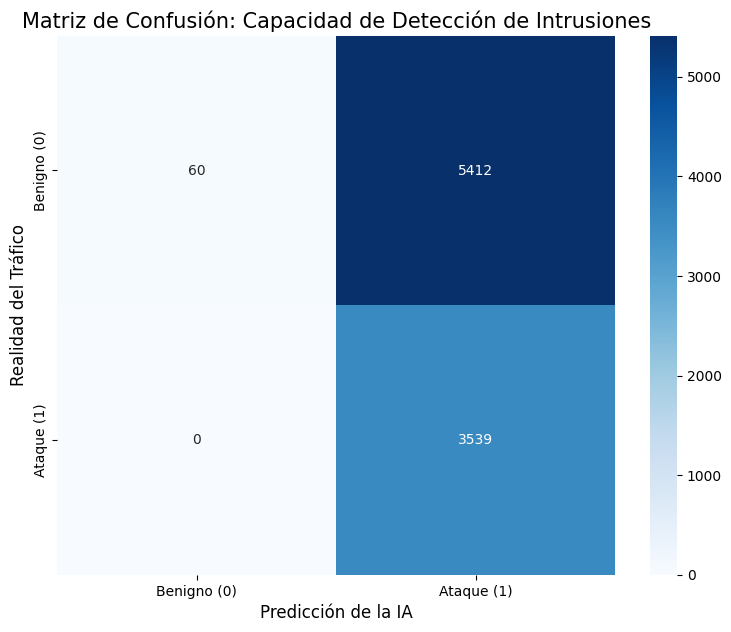


             REPORTE TÉCNICO DE CLASIFICACIÓN
              precision    recall  f1-score   support

     Benigno       1.00      0.01      0.02      5472
      Ataque       0.40      1.00      0.57      3539

    accuracy                           0.40      9011
   macro avg       0.70      0.51      0.29      9011
weighted avg       0.76      0.40      0.24      9011



In [17]:
# Realizar predicciones sobre el set de test
y_pred = modelo.predict(X_test_scaled)

# Configuración visual de la matriz
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benigno (0)', 'Ataque (1)'], 
            yticklabels=['Benigno (0)', 'Ataque (1)'])

plt.title('Matriz de Confusión: Capacidad de Detección de Intrusiones', fontsize=15)
plt.xlabel('Predicción de la IA', fontsize=12)
plt.ylabel('Realidad del Tráfico', fontsize=12)
plt.show()

# Resumen estadístico para el TFG
print("\n" + "="*55)
print("             REPORTE TÉCNICO DE CLASIFICACIÓN")
print("="*55)
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Ataque']))

/tmp/ipykernel_965/553611944.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Métrica de Red', data=importancias.head(12), palette='viridis')


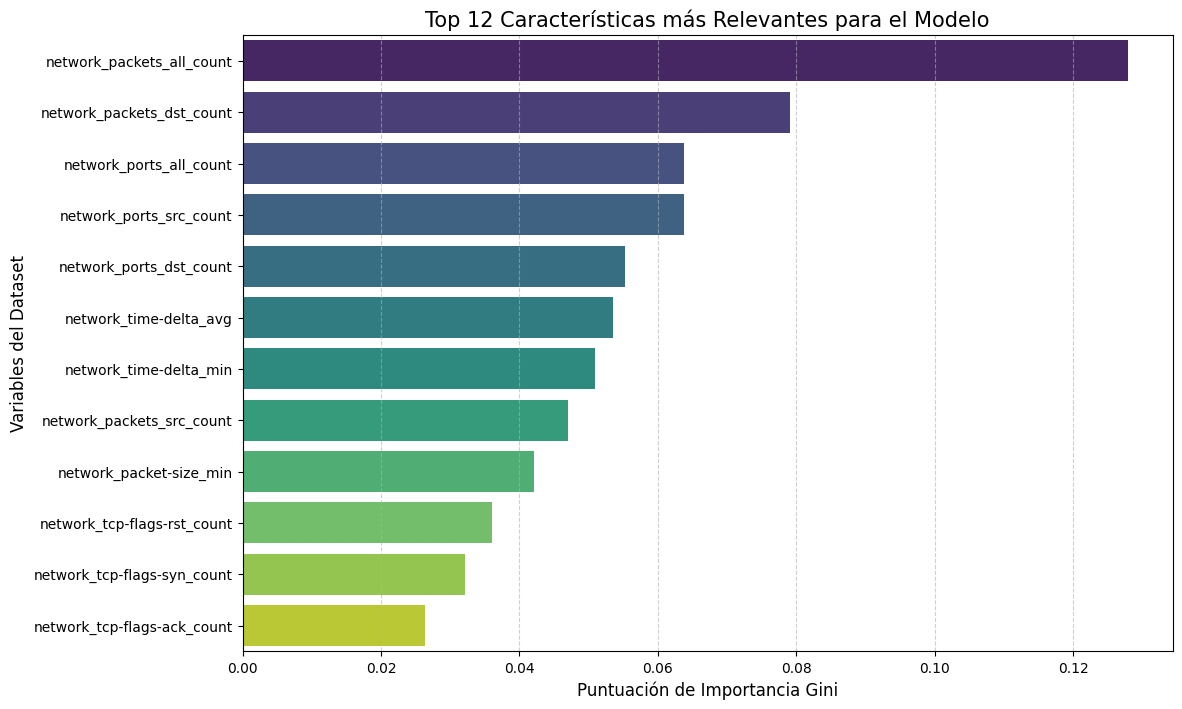


--- Tabla de importancia (Top 5) ---
               Métrica de Red  Importancia
36  network_packets_all_count     0.127960
37  network_packets_dst_count     0.079139
43    network_ports_all_count     0.063852
45    network_ports_src_count     0.063777
44    network_ports_dst_count     0.055196


In [18]:
# Extracción de la sabiduría del Random Forest
importancias = pd.DataFrame({
    'Métrica de Red': features,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización del Top 12 (las más críticas)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Métrica de Red', data=importancias.head(12), palette='viridis')

plt.title('Top 12 Características más Relevantes para el Modelo', fontsize=15)
plt.xlabel('Puntuación de Importancia Gini', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Mostrar la tabla de datos para análisis escrito
print("\n--- Tabla de importancia (Top 5) ---")
print(importancias.head(5))